In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Código Lista Arquivos

In [7]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/final_data.csv
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-pub

## Carrega Tabelas Principais

In [8]:
import pandas as pd

# 1. Carregando as tabelas principais
path_base = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'

pedidos = pd.read_csv(path_base + 'olist_orders_dataset.csv')
itens = pd.read_csv(path_base + 'olist_order_items_dataset.csv')
clientes = pd.read_csv(path_base + 'olist_customers_dataset.csv')

# 2. Fazendo o MERGE (Unindo as peças do quebra-cabeça)
# Primeiro: unimos ITENS com PEDIDOS usando o 'order_id'
df_vendas = pd.merge(itens, pedidos, on='order_id')

# Segundo: unimos o resultado com CLIENTES usando o 'customer_id'
df_final = pd.merge(df_vendas, clientes, on='customer_id')

# 3. Verificando o resultado
print("Tamanho do dataset final:", df_final.shape)
df_final[['order_id', 'price', 'customer_state', 'order_purchase_timestamp']].head()

Tamanho do dataset final: (112650, 18)


,order_id,price,customer_state,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,RJ,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,239.90,SP,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,199.00,MG,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,12.99,SP,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,SP,2017-02-04 13:57:51


## Agrupando por Estado (UF) e somando o Preço

/tmp/ipykernel_55/2855935372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_estado, x='customer_state', y='price', palette='viridis')


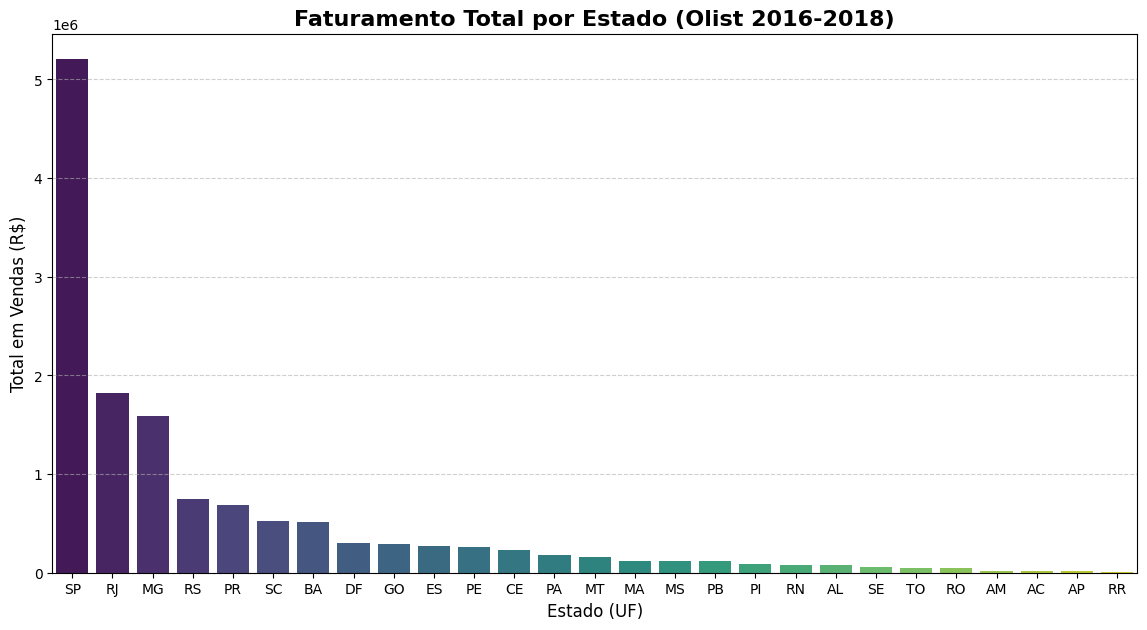

--- TOP 3 ESTADOS EM FATURAMENTO ---
  customer_state       price
0             SP  5202955.05
1             RJ  1824092.67
2             MG  1585308.03


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupando por Estado (UF) e somando o Preço
faturamento_estado = df_final.groupby('customer_state')['price'].sum().sort_values(ascending=False).reset_index()

# 2. Criando o gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(data=faturamento_estado, x='customer_state', y='price', palette='viridis')

# 3. Estilizando o gráfico (Padrão Profissional)
plt.title('Faturamento Total por Estado (Olist 2016-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Total em Vendas (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Exibindo os números reais do Top 3
print("--- TOP 3 ESTADOS EM FATURAMENTO ---")
print(faturamento_estado.head(3))

## Convertendo as colunas para o formato de DATA (Datetime)

/tmp/ipykernel_55/2559067654.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_entrega_uf.head(10), x='delivery_time', y='customer_state', palette='Reds_r')


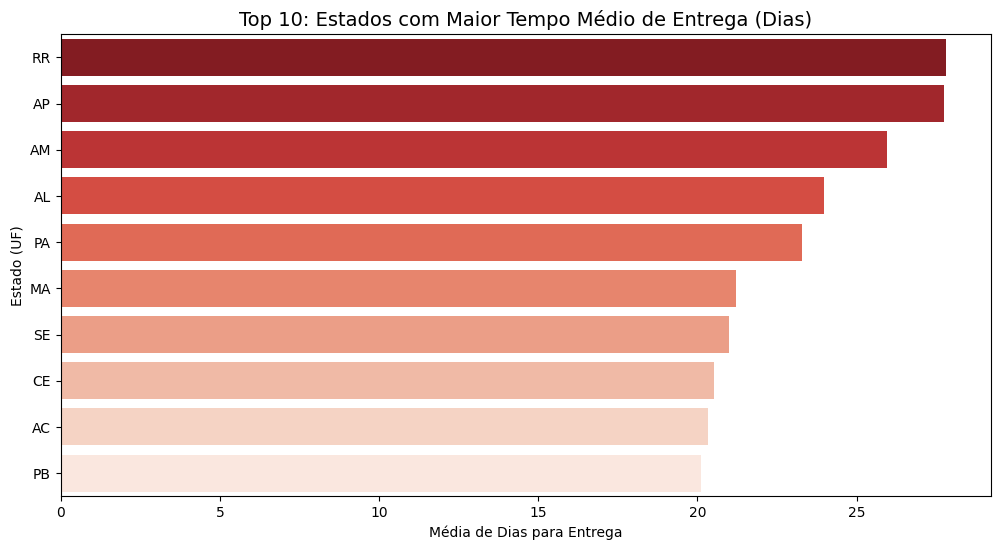

Média Geral de Entrega no Brasil: 12.0 dias


In [10]:
import pandas as pd

# 1. Convertendo as colunas para o formato de DATA (Datetime)
# Se não fizermos isso, o Python não consegue fazer a conta de "menos"
df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])
df_final['order_delivered_customer_date'] = pd.to_datetime(df_final['order_delivered_customer_date'])

# 2. Calculando a diferença (Tempo de Entrega em dias)
# Criamos uma nova coluna chamada 'delivery_time'
df_final['delivery_time'] = (df_final['order_delivered_customer_date'] - df_final['order_purchase_timestamp']).dt.days

# 3. Removendo valores nulos (pedidos que ainda não foram entregues ou cancelados)
df_entrega = df_final.dropna(subset=['delivery_time'])

# 4. Calculando a Média de Dias por Estado
media_entrega_uf = df_entrega.groupby('customer_state')['delivery_time'].mean().sort_values(ascending=False).reset_index()

# 5. Visualizando os Top 10 Estados com Entrega mais Lenta
plt.figure(figsize=(12, 6))
sns.barplot(data=media_entrega_uf.head(10), x='delivery_time', y='customer_state', palette='Reds_r')
plt.title('Top 10: Estados com Maior Tempo Médio de Entrega (Dias)', fontsize=14)
plt.xlabel('Média de Dias para Entrega')
plt.ylabel('Estado (UF)')
plt.show()

print(f"Média Geral de Entrega no Brasil: {df_entrega['delivery_time'].mean():.1f} dias")

## Carregando a tabela de avaliações (Reviews)

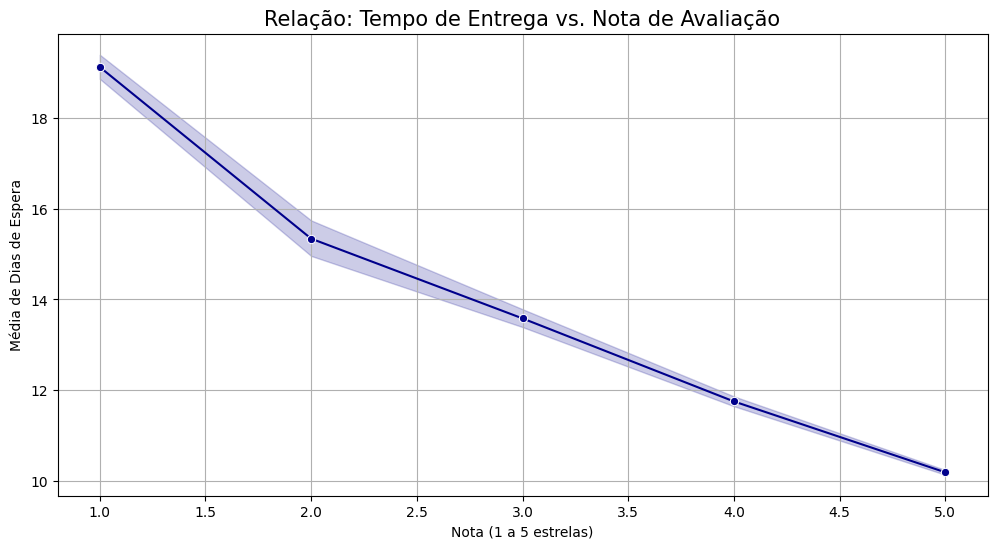

review_score
1    19.116632
2    15.337838
3    13.581197
4    11.752644
5    10.191464
Name: delivery_time, dtype: float64


In [11]:
# 1. Carregando a tabela de avaliações (Reviews)
path_reviews = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv'
reviews = pd.read_csv(path_reviews)

# 2. Unindo com o nosso dataset de entregas
df_satisfacao = pd.merge(df_entrega, reviews, on='order_id')

# 3. Criando um gráfico de dispersão (Scatter Plot) 
# Queremos ver: Quanto mais dias (X), menor a nota (Y)?
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_satisfacao, x='review_score', y='delivery_time', marker='o', color='darkblue')

plt.title('Relação: Tempo de Entrega vs. Nota de Avaliação', fontsize=15)
plt.xlabel('Nota (1 a 5 estrelas)')
plt.ylabel('Média de Dias de Espera')
plt.grid(True)
plt.show()

# Média de dias para quem deu nota 1 vs nota 5
print(df_satisfacao.groupby('review_score')['delivery_time'].mean())

## Criando colunas de Ano e Mês para análise temporal

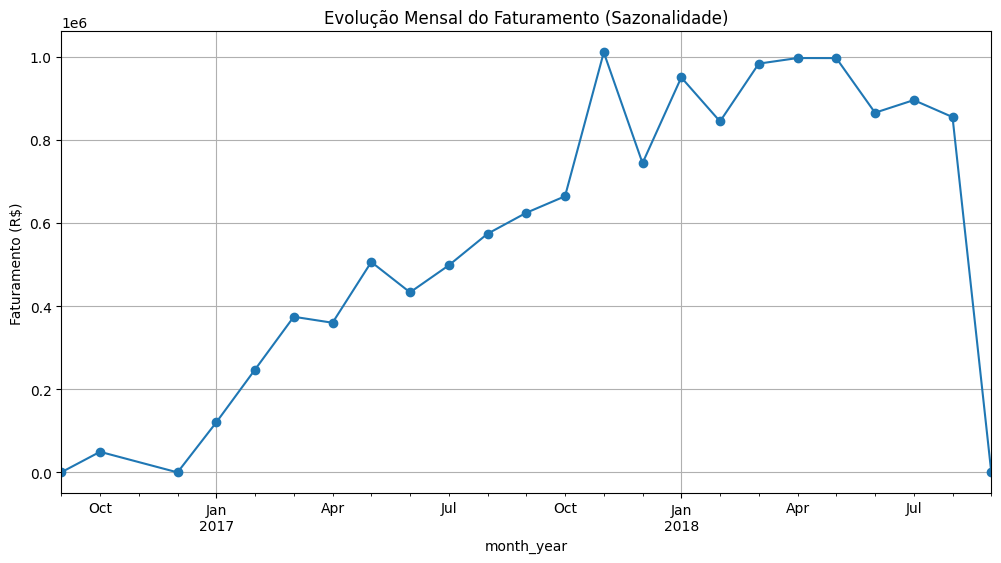

In [12]:
# Criando colunas de Ano e Mês para análise temporal
df_final['month_year'] = df_final['order_purchase_timestamp'].dt.to_period('M')

# Agrupando vendas por mês
vendas_mensais = df_final.groupby('month_year')['price'].sum().plot(kind='line', figsize=(12,6), marker='o')

plt.title('Evolução Mensal do Faturamento (Sazonalidade)')
plt.ylabel('Faturamento (R$)')
plt.grid(True)
plt.show()

## Carregar tradução e produtos

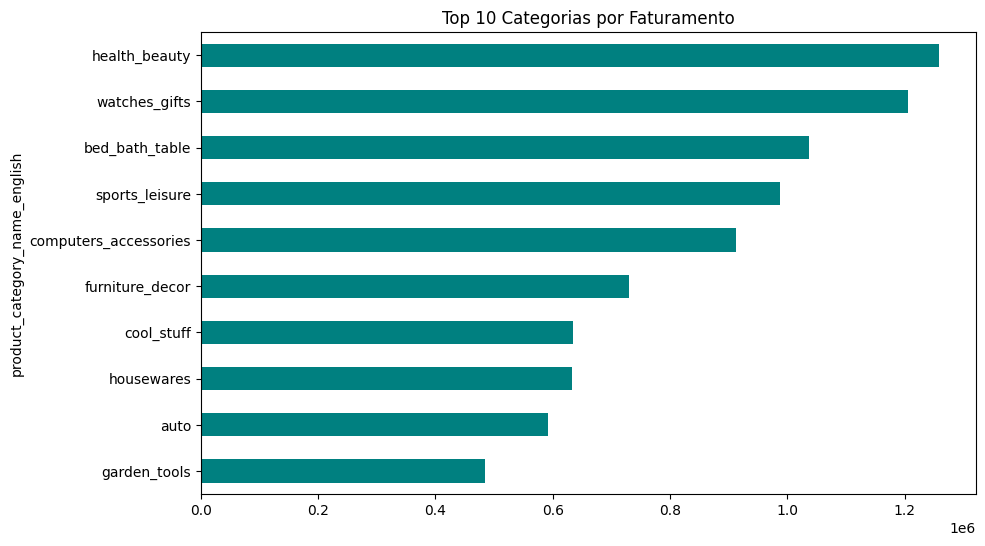

In [13]:
# 1. Carregar tradução e produtos
produtos = pd.read_csv(path_base + 'olist_products_dataset.csv')
traducao = pd.read_csv(path_base + 'product_category_name_translation.csv')

# 2. Merge para ter o nome da categoria no DF final
df_prod = pd.merge(df_final, produtos, on='product_id')
df_prod = pd.merge(df_prod, traducao, on='product_category_name')

# 3. Top 10 categorias mais rentáveis
top_categorias = df_prod.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
top_categorias.plot(kind='barh', figsize=(10,6), color='teal').invert_yaxis()
plt.title('Top 10 Categorias por Faturamento')
plt.show()

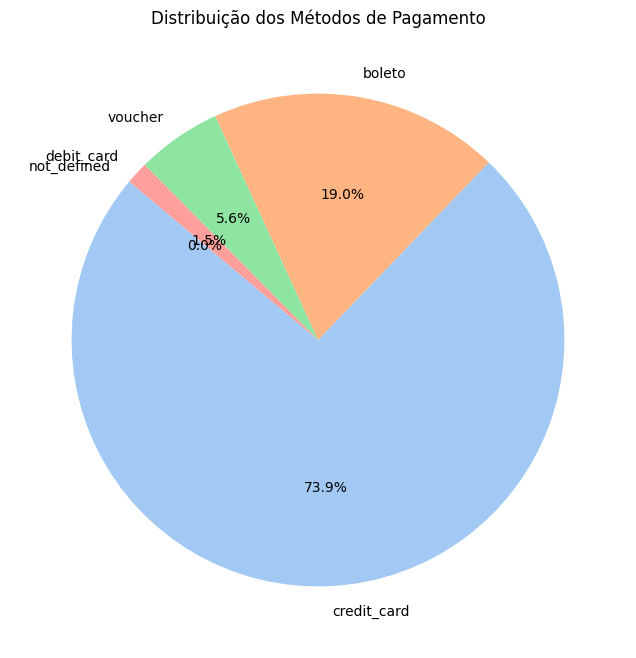

In [14]:
pagamentos = pd.read_csv(path_base + 'olist_order_payments_dataset.csv')
tipos_pagamento = pagamentos['payment_type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(tipos_pagamento, labels=tipos_pagamento.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribuição dos Métodos de Pagamento')
plt.show()

## Garantindo que a coluna de data seja do tipo Datetime

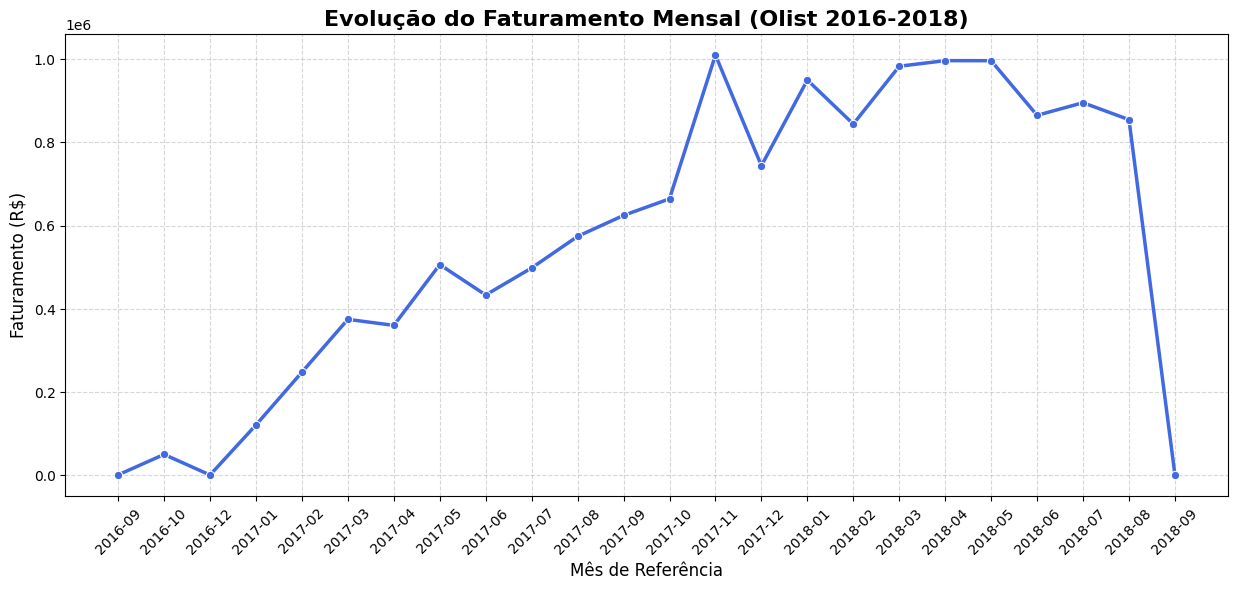

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantindo que a coluna de data seja do tipo Datetime
df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])

# 2. Criando uma coluna de Ano-Mês para agrupar (Ex: 2017-11)
df_final['month_year'] = df_final['order_purchase_timestamp'].dt.to_period('M')

# 3. Agrupando o faturamento por mês
vendas_mensais = df_final.groupby('month_year')['price'].sum().reset_index()

# Convertendo de volta para string para o gráfico conseguir ler o eixo X
vendas_mensais['month_year'] = vendas_mensais['month_year'].astype(str)

# 4. Plotando o Gráfico de Linha (Série Temporal)
plt.figure(figsize=(15, 6))
sns.lineplot(data=vendas_mensais, x='month_year', y='price', marker='o', color='royalblue', linewidth=2.5)

# Ajustes estéticos
plt.title('Evolução do Faturamento Mensal (Olist 2016-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Mês de Referência', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(rotation=45) # Inclina as datas para não embolar
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sns as sns # Certifique-se que o seaborn está como sns

# 1. Carregando as tabelas de apoio
produtos = pd.read_csv(path_base + 'olist_products_dataset.csv')
traducao = pd.read_csv(path_base + 'product_category_name_translation.csv')

# 2. Unindo os produtos com suas traduções (Português -> Inglês)
df_prod_nomes = pd.merge(produtos, traducao, on='product_category_name')

# 3. Unindo com o nosso DataFrame principal (df_final) para ter o PREÇO
df_completo = pd.merge(df_final, df_prod_nomes, on='product_id')

# 4. Agrupando por Categoria e somando o Faturamento
top_10_cats = df_completo.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

# 5. Criando o Gráfico
plt.figure(figsize=(12, 8))
top_10_cats.plot(kind='barh', color='darkcyan').invert_yaxis()

# Estética Profissional
plt.title('Top 10 Categorias por Faturamento (R$)', fontsize=15, fontweight='bold')
plt.xlabel('Total em Vendas')
plt.ylabel('Categoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print("A categoria campeã de vendas é:", top_10_cats.index[0])

ModuleNotFoundError: No module named 'sns'

## Carregando as tabelas de apoio 

/tmp/ipykernel_55/2144508947.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cats.values, y=top_10_cats.index, palette='magma')


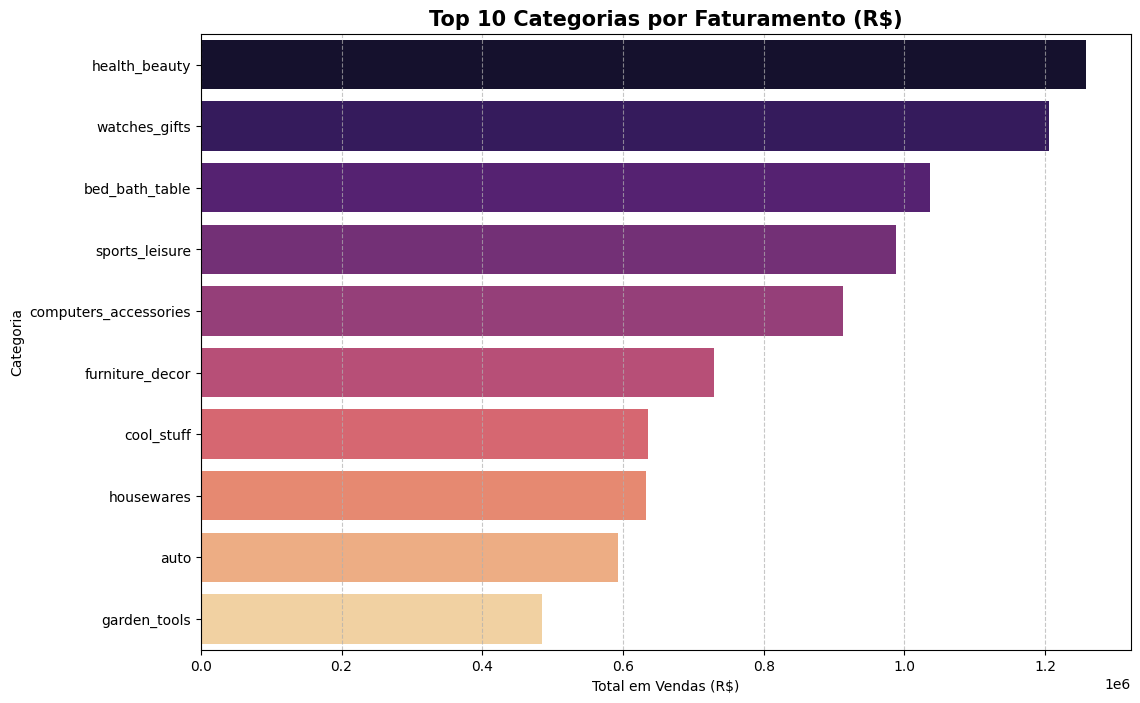

A categoria campeã de vendas é: health_beauty


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # O nome correto do módulo é seaborn

# 1. Carregando as tabelas de apoio (usando o caminho que você já validou)
path_base = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'
produtos = pd.read_csv(path_base + 'olist_products_dataset.csv')
traducao = pd.read_csv(path_base + 'product_category_name_translation.csv')

# 2. Unindo os produtos com suas traduções (Português -> Inglês)
df_prod_nomes = pd.merge(produtos, traducao, on='product_category_name')

# 3. Unindo com o seu DataFrame principal (df_final) para ter o PREÇO
# Se o seu df_final não estiver na memória, lembre-se de rodar a célula do merge anterior
df_completo = pd.merge(df_final, df_prod_nomes, on='product_id')

# 4. Agrupando por Categoria e somando o faturamento
top_10_cats = df_completo.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

# 5. Criando o Gráfico com Seaborn (sns)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_cats.values, y=top_10_cats.index, palette='magma')

# Estética Profissional
plt.title('Top 10 Categorias por Faturamento (R$)', fontsize=15, fontweight='bold')
plt.xlabel('Total em Vendas (R$)')
plt.ylabel('Categoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print("A categoria campeã de vendas é:", top_10_cats.index[0])